In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from nemosis import dynamic_data_compiler
import os


os.makedirs('./data/nemosis_cache', exist_ok=True)
CACHE = './data/nemosis_cache'


prices = dynamic_data_compiler(
    '2025/01/01 00:00:00',
    '2026/01/01 00:00:00',
    'DISPATCHPRICE', CACHE,
    fformat='parquet',
    filter_cols=['INTERVENTION'],
    filter_values=([0],)
)

prices = prices[['SETTLEMENTDATE', 'REGIONID', 'RRP', 'PRICE_STATUS']].copy()

print(prices.head(20))

offset = pd.Timedelta('5min')

# Pivot to wide format — this is your working DataFrame for everything
prices_wide = (prices
    .pivot(index='SETTLEMENTDATE', columns='REGIONID', values='RRP')
    .sort_index()
)
prices_wide.index = prices_wide.index - offset

# PRICE_STATUS wide — same shape/index, use for masking administered periods
price_status_wide = (prices
    .pivot(index='SETTLEMENTDATE', columns='REGIONID', values='PRICE_STATUS')
    .sort_index()
)
price_status_wide.index = price_status_wide.index - offset

print()
print(prices_wide.head())
print(f"Shape: {prices_wide.shape}")
print(f"Memory: {prices_wide.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\nPRICE_STATUS value counts (all regions):")
print(price_status_wide.apply(pd.Series.value_counts).fillna(0).astype(int))

print("\nHow many price cap intervals were there?")
cap_events = (prices_wide >= 15000).sum()
print(cap_events)

print("\nHow many negative price intervals?")
neg_prices = (prices_wide < 0).sum()
print(neg_prices)

print(prices_wide.describe())

INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
        SETTLEMENTDATE REGIONID        RRP PRICE_STATUS
0  2025-01-01 00:05:00     NSW1  138.02790         FIRM
1  2025-01-01 00:05:00     QLD1  154.30294         FIRM
2  2025-01-01 00:05:00      SA1  141.47720         FIRM
3  2025-01-01 00:05:00     TAS1  125.17761         FIRM
4  2025-01-01 00:05:00     VIC1  130.00000         FIRM
5  2025-01-01 00:10:00     NSW1  134.41651         FIRM
6  2025-01-01 00:10:00     QLD1  150.42180         FIRM
7  2025-01-01 00:10:00      SA1  136.58563         FIRM
8  2025-01-01 00:10:00     TAS1  120.28000         FIRM
9  2025-01-01 00:10:00     VIC1  125.50000         FIRM
10 2025-01-01 00:15:00     NSW1  135.89000         FIRM
11 2025-01-01 00:15:00     QLD1  150.07326         FIRM
12 2025-01-01 00:15:00      SA1  142.05217         FIRM
13 2025-01-01 00:15:00     TAS1  129.97176         FIRM
14 2025-01-01 00:15:00     VIC1  129.02340         FIRM
15 2025-01-01 00:20:00     N

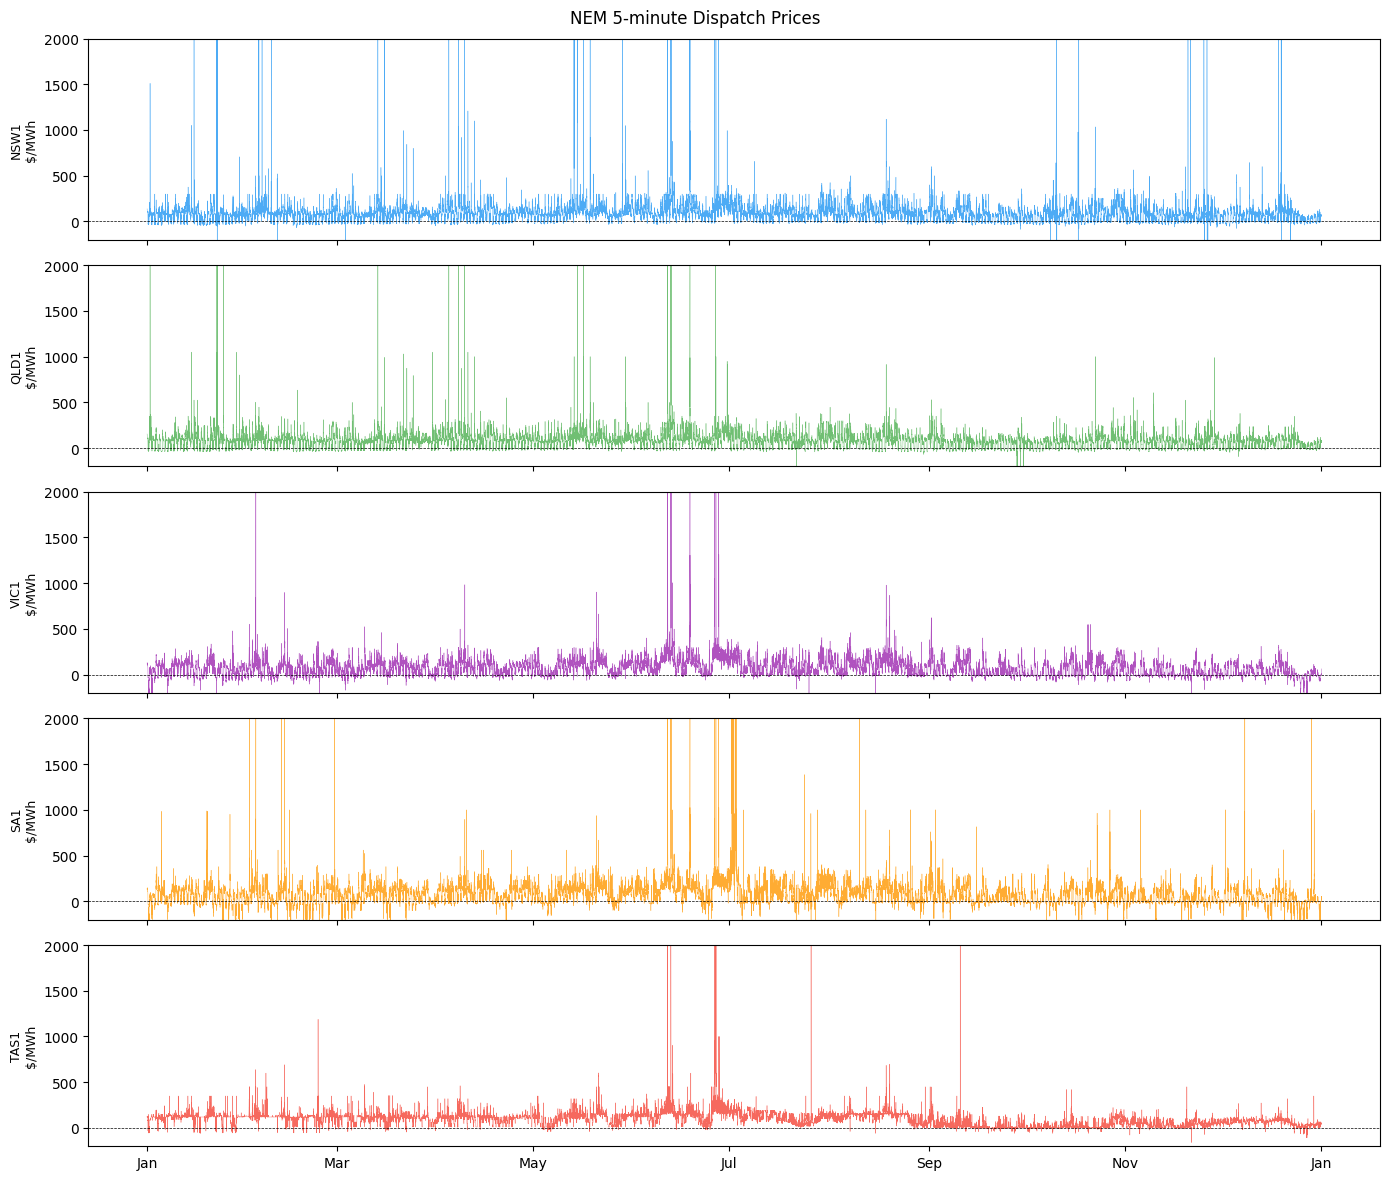

In [2]:
# Time Series Plot

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
regions = ['NSW1', 'QLD1', 'VIC1', 'SA1', 'TAS1']
colors  = ['#2196F3', '#4CAF50', '#9C27B0', '#FF9800', '#F44336']

for ax, region, color in zip(axes, regions, colors):
    # Cap display at 2000 for readability — spikes exist but obscure everything
    display = prices_wide[region].clip(upper=2000)
    ax.plot(display.index, display, lw=0.3, color=color, alpha=0.8)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_ylabel(f'{region}\n$/MWh', fontsize=9)
    ax.set_ylim(-200, 2000)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.suptitle('NEM 5-minute Dispatch Prices', fontsize=12)
plt.tight_layout()

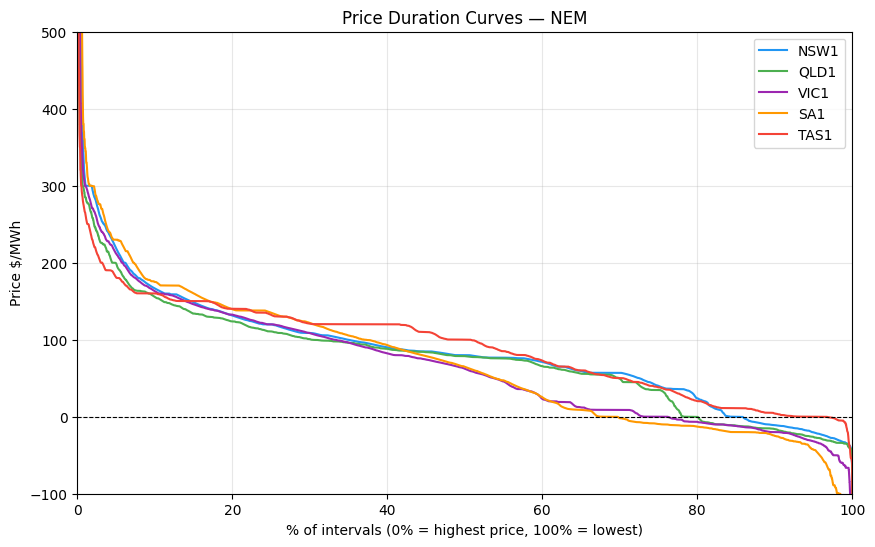

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

for region, color in zip(regions, colors):
    sorted_prices = prices_wide[region].sort_values(ascending=False).values
    pct = (np.arange(len(sorted_prices)) / len(sorted_prices)) * 100  # x-axis: % of intervals
    ax.plot(pct, sorted_prices, label=region, color=color, lw=1.5)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlim(0, 100)
ax.set_ylim(-100, 500)   # zoom in on the bulk — spikes distort the top
ax.set_xlabel('% of intervals (0% = highest price, 100% = lowest)')
ax.set_ylabel('Price $/MWh')
ax.set_title('Price Duration Curves — NEM')
ax.legend()
ax.grid(alpha=0.3)

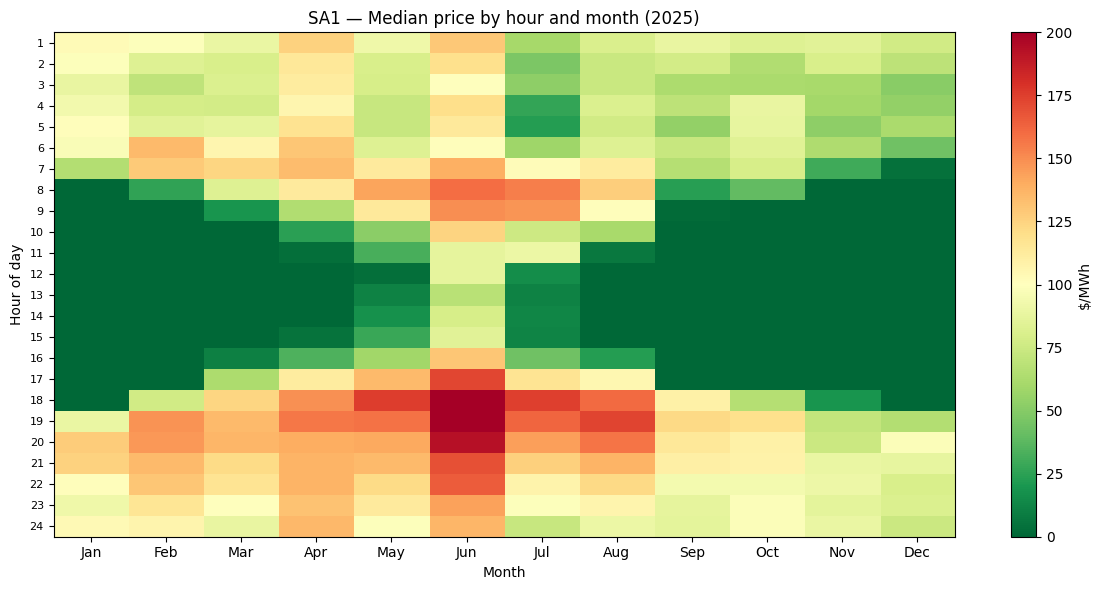

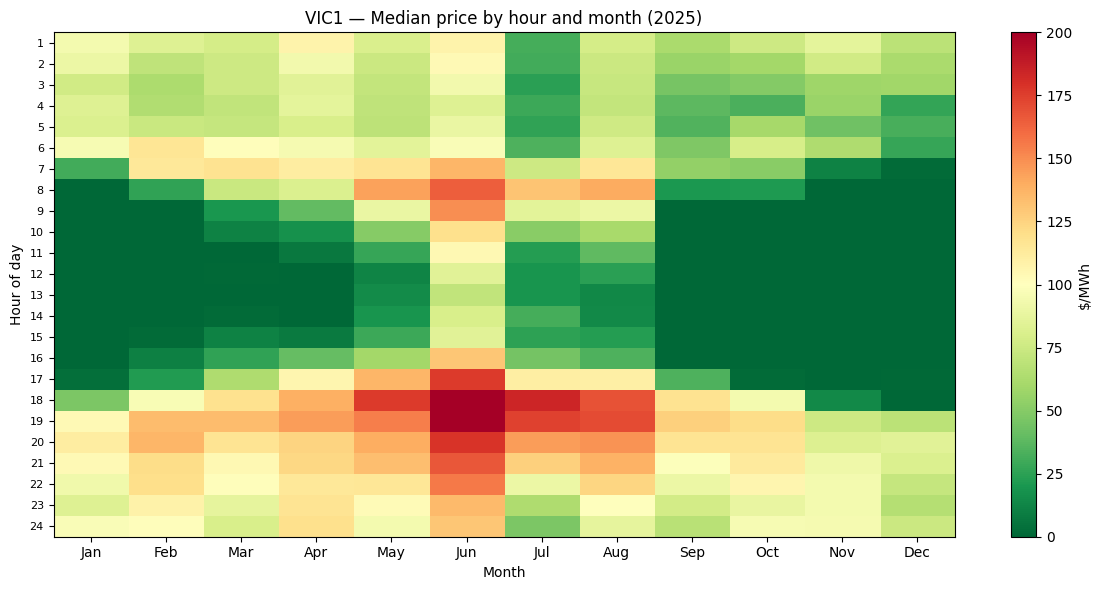

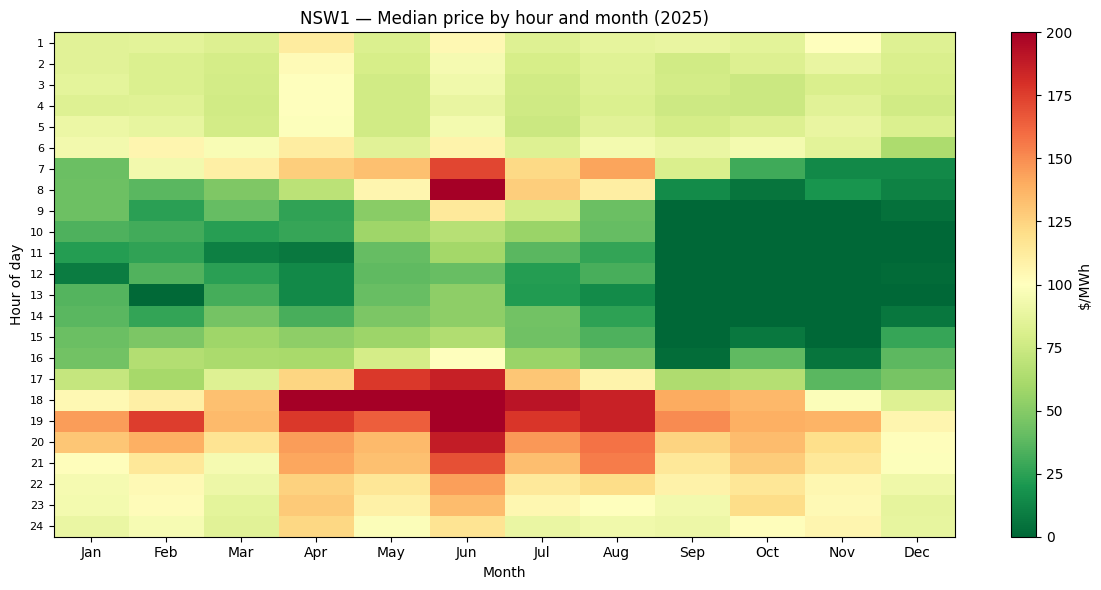

In [ ]:
# Resample to hourly — takes the mean of the 12 x 5-min intervals in each hour
prices_hourly = prices_wide.resample('1h').mean()

for region in ['SA1', 'VIC1', 'NSW1']:
    df = prices_hourly[[region]].copy()
    
    # Hour bucket 1–24 (not 0–23)
    df['hour'] = df.index.hour + 1      # shifts 0-23 → 1-24
    df['month'] = df.index.month
    
    pivot = df.pivot_table(
        values=region,
        index='hour',       # 1–24, 24 rows
        columns='month',
        aggfunc='median'
    )
    
    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(pivot, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=200)
    
    ax.set_xlabel('Month')
    ax.set_ylabel('Hour of day')
    ax.set_yticks(range(24))
    ax.set_yticklabels(range(1, 25), fontsize=8)
    ax.set_title(f'{region} — Median price by hour and month')
    ax.set_xticks(range(12))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.colorbar(im, label='$/MWh')
    plt.tight_layout()
    plt.show()

Text(0.5, 1.0, 'Distribution of SA-VIC spread')

/home/jask/jaskNEM/.venv/lib/python3.11/site-packages/IPython/core/events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/jask/jaskNEM/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


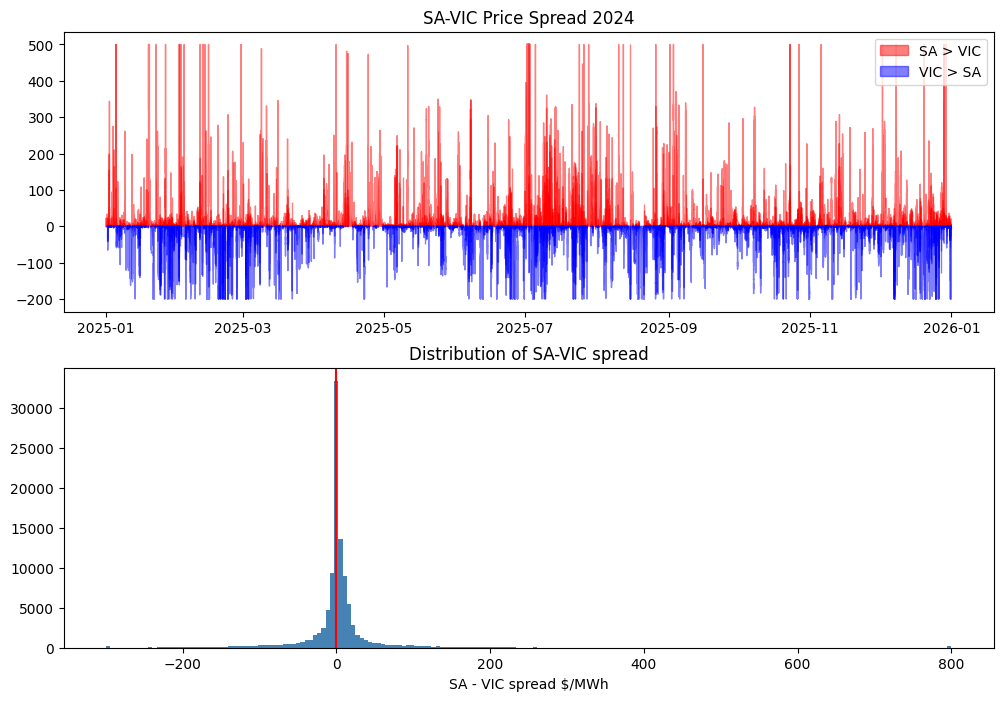

In [5]:
# SA-VIC spread — positive means SA is more expensive than VIC
spread = prices_wide['SA1'] - prices_wide['VIC1']

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top: raw spread time series
axes[0].fill_between(spread.index, spread.clip(-200, 500), 0,
                     where=spread > 0, alpha=0.5, color='red',   label='SA > VIC')
axes[0].fill_between(spread.index, spread.clip(-200, 500), 0,
                     where=spread < 0, alpha=0.5, color='blue',  label='VIC > SA')
axes[0].set_title('SA-VIC Price Spread 2024')
axes[0].legend()

# Bottom: spread distribution
axes[1].hist(spread.clip(-300, 800), bins=200, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', lw=1.5)
axes[1].set_xlabel('SA - VIC spread $/MWh')
axes[1].set_title('Distribution of SA-VIC spread')

In [6]:
june = prices_wide['2025-06-01':'2025-06-30']['SA1']
print(june.describe())
print(june.value_counts().head(10))  # repeated values = administered pricing
print(f"Intervals >= 500: {(june >= 500).sum()}")
print(f"Intervals < 0: {(june < 0).sum()}")

count     8640.000000
mean       250.404828
std       1078.598835
min       -278.805560
25%         51.304675
50%        138.000000
75%        193.983783
max      16983.462880
Name: SA1, dtype: float64
SA1
 138.00    240
-21.00     218
 130.44    183
 170.44    146
 175.05    100
 138.04     81
 299.44     71
 99.45      58
-8.00       55
 230.00     53
Name: count, dtype: int64
Intervals >= 500: 226
Intervals < 0: 1213


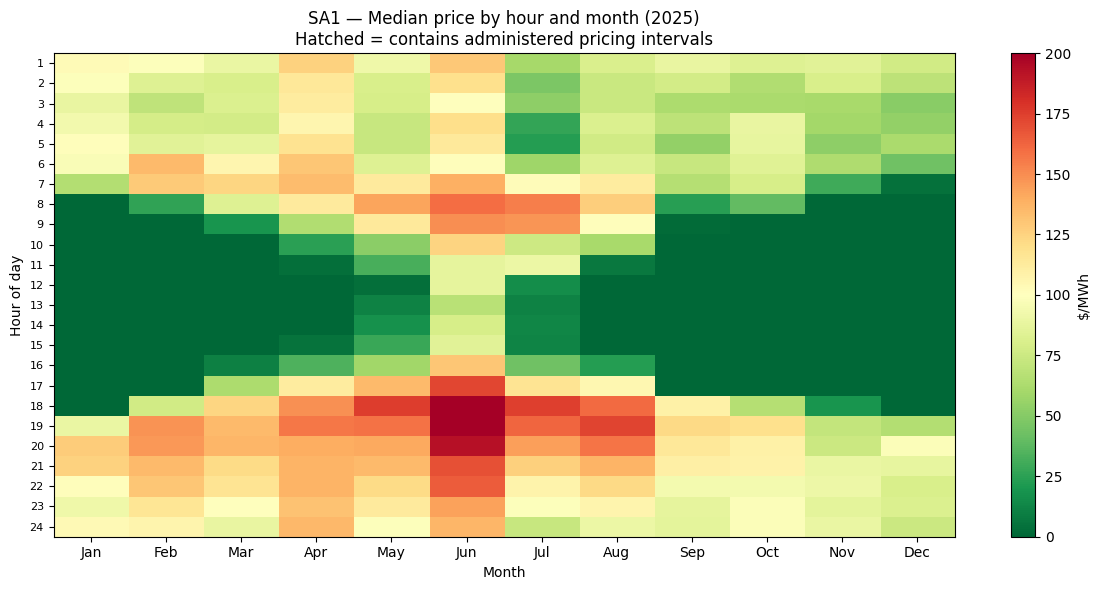

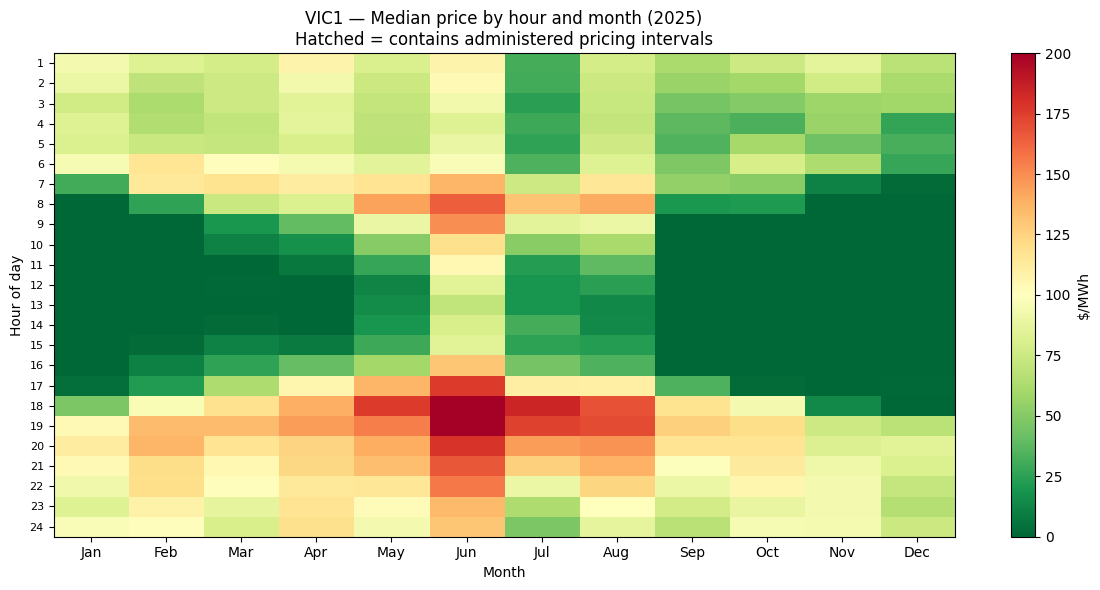


Administered pricing summary by region:
  NSW1: no administered intervals
  QLD1: no administered intervals
  SA1: no administered intervals
  TAS1: no administered intervals
  VIC1: no administered intervals


In [9]:
# Resample prices to hourly
prices_hourly = prices_wide.resample('1h').mean()

# For status: an hour is "administered" if ANY interval within it was administered
# Convert to boolean first (True = administered), then resample with max (any=True → True)
administered_bool = (price_status_wide != 'FIRM')
administered_hourly = administered_bool.resample('1h').max()  # True if any 5-min was administered

for region in ['SA1', 'VIC1']:
    df = prices_hourly[[region]].copy()
    df['hour'] = df.index.hour + 1
    df['month'] = df.index.month

    # Same shape pivot for the administered mask
    adm = administered_hourly[[region]].copy()
    adm['hour'] = adm.index.hour + 1
    adm['month'] = adm.index.month

    pivot = df.pivot_table(
        values=region, index='hour', columns='month', aggfunc='median'
    )
    
    # Mask pivot: what fraction of hours in each cell were administered?
    adm_pivot = adm.pivot_table(
        values=region, index='hour', columns='month', aggfunc='mean'  # mean of booleans = fraction
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(pivot, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=200)

    # Hatch over cells where >0% of hours were administered
    # imshow cells are indexed [row, col] = [hour_idx, month_idx]
    for row_idx in range(24):
        for col_idx in range(12):
            month = col_idx + 1
            hour = row_idx + 1
            if month in adm_pivot.columns and hour in adm_pivot.index:
                frac = adm_pivot.loc[hour, month]
                if frac > 0:
                    # Draw a hatched rectangle over this cell
                    ax.add_patch(plt.Rectangle(
                        (col_idx - 0.5, row_idx - 0.5), 1, 1,
                        fill=False, hatch='////', edgecolor='white',
                        linewidth=0, alpha=0.8
                    ))
                    # If heavily administered (>50% of hours), add a dot marker too
                    if frac > 0.5:
                        ax.text(col_idx, row_idx, '●', ha='center', va='center',
                                color='white', fontsize=6)

    ax.set_xlabel('Month')
    ax.set_ylabel('Hour of day')
    ax.set_yticks(range(24))
    ax.set_yticklabels(range(1, 25), fontsize=8)
    ax.set_title(f'{region} — Median price by hour and month (2025)\n'
                 f'Hatched = contains administered pricing intervals')
    ax.set_xticks(range(12))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.colorbar(im, label='$/MWh')
    plt.tight_layout()
    plt.show()

# Also print a summary of administered periods so you know what you're masking
print("\nAdministered pricing summary by region:")
for region in ['NSW1', 'QLD1', 'SA1', 'TAS1', 'VIC1']:
    n_intervals = administered_bool[region].sum()
    if n_intervals > 0:
        # Find the date ranges
        adm_times = price_status_wide.index[administered_bool[region]]
        print(f"  {region}: {n_intervals} intervals | "
              f"{adm_times.min().date()} → {adm_times.max().date()}")
    else:
        print(f"  {region}: no administered intervals")